# GP-GLLVM prototype — correlated latents & block encoder (playground)

A **Gaussian-process latent GLLVM** (standalone, does not touch `/src`). Each latent
factor is a GP over an input $t_i$ (time/space/pseudotime):
$$\varepsilon_{:,k}\sim N(0,I),\quad z_{:,k}=L\,\varepsilon_{:,k}\ (L=\mathrm{chol}\,K(t)),\quad y_i\sim\mathrm{Poisson}(e^{Wz_i+b}).$$
So the latents are **correlated across observations**, but marginally each $z_i\sim N(0,I)$.

**Key GP fact used throughout:** the marginal of the GP over *any* subset of $K$
points is exactly $N(0,K_{\text{block}})$. So a block of $K$ observations is itself a
valid GP draw — which is why the estimator can use tiny $K\times K$ blocks ($K\approx
10$–$20$) and never invert the full $n\times n$.

**Encoder = ordinary Gaussian-MAP + one extra step.** For a block $(y_{\text{block}},
t_{\text{block}})$:
1. per-observation MAP $\to \hat Z$ (K×q), *correlated* (it estimates the correlated $z$'s);
2. **whiten** by the block kernel: $\hat\varepsilon = L_{\text{block}}^{-1}\hat Z$ → the
   independent realization (the generator's starting point).

This notebook shows (i) the latents are GP-correlated, (ii) the correlation equals the
kernel, (iii) the encoder recovers the correlated latent, and (iv) the whitening step
de-correlates it.

In [1]:
import sys, os, numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else ".")
from gp_gllvm import GPGLLVM, GPMapEncoder
plt.rcParams.update({"figure.dpi": 110})
torch.manual_seed(0)

gp = GPGLLVM(latent_dim=2, output_dim=30, lengthscale=2.0, kernel_var=1.0, wz_scale=0.7, seed=0)
enc = GPMapEncoder(gp)
t = torch.sort(torch.rand(200) * 20).values            # inputs on [0,20]
with torch.no_grad():
    y, z, eps = gp.sample(t, seed=1)
print(f"n={len(t)}  p={gp.p}  q={gp.q}  lengthscale={gp.lengthscale}  "
      f"y range [{int(y.min())},{int(y.max())}]")

n=200  p=30  q=2  lengthscale=2.0  y range [0,30]


## 1 · The latents are GP-correlated across observations

`z(t)` are smooth GP draws (neighbouring observations share latent value); the
underlying white realization `eps(t)` is uncorrelated noise.

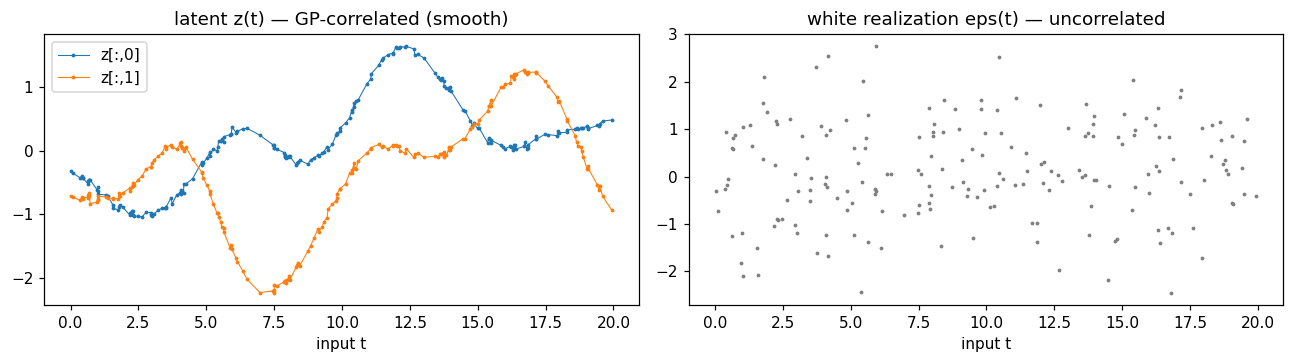

In [2]:
ts = t.numpy()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(ts, z[:, 0].numpy(), ".-", ms=3, lw=.7, label="z[:,0]")
ax[0].plot(ts, z[:, 1].numpy(), ".-", ms=3, lw=.7, label="z[:,1]")
ax[0].set_title("latent z(t) — GP-correlated (smooth)"); ax[0].set_xlabel("input t"); ax[0].legend()
ax[1].plot(ts, eps[:, 0].numpy(), ".", ms=3, color="gray")
ax[1].set_title("white realization eps(t) — uncorrelated"); ax[1].set_xlabel("input t")
plt.tight_layout(); plt.show()

## 2 · The induced correlation **equals the kernel**

Empirical correlation of `z` over a contiguous block of $K=20$ (across many GP
realizations) matches the RBF kernel block $K_{\text{block}}$.

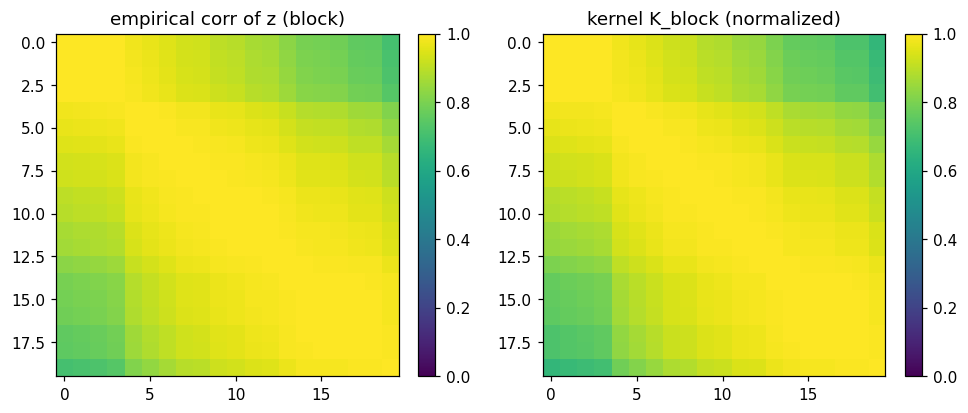

off-diagonal mean: empirical corr(z)=0.931   kernel=0.921


In [3]:
K = 20; i0 = 90; idx = slice(i0, i0 + K); tb = t[idx]
with torch.no_grad():
    yB, zB, epsB = gp.sample_batch(t, R=400, seed=7)      # (R,n,*)
zblk = zB[:, idx, 0].numpy()                              # (R,K) latent dim 0 over the block
Cz = np.corrcoef(zblk.T)
Kb = gp.kernel(tb).numpy(); Kb = Kb / Kb[0, 0]           # normalized kernel block
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, M, ttl in [(ax[0], Cz, "empirical corr of z (block)"), (ax[1], Kb, "kernel K_block (normalized)")]:
    im = a.imshow(M, vmin=0, vmax=1, cmap="viridis"); a.set_title(ttl); plt.colorbar(im, ax=a, fraction=.046)
plt.tight_layout(); plt.show()
od = lambda M: float(np.mean(np.abs(M[~np.eye(M.shape[0], dtype=bool)])))
print(f"off-diagonal mean: empirical corr(z)={od(Cz):.3f}   kernel={od(Kb):.3f}")

## 3 · Encoder step 1 — per-obs MAP recovers the (correlated) latent

Apply the ordinary Gaussian-MAP to the block. $\hat Z$ tracks the true (correlated)
$z_{\text{block}}$.

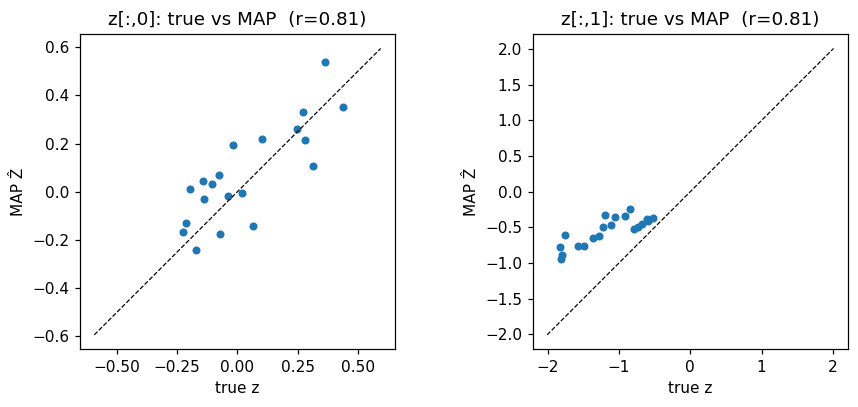

In [4]:
with torch.no_grad():
    Zhat, eps_hat = enc.encode_block(y[idx], tb)
zt = z[idx].numpy()
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.8))
for k in range(2):
    ax[k].scatter(zt[:, k], Zhat[:, k].numpy(), s=18);
    lim = 1.1*np.abs(np.r_[zt[:,k], Zhat[:,k].numpy()]).max()
    ax[k].plot([-lim,lim],[-lim,lim],"k--",lw=.8); ax[k].set_aspect("equal")
    ax[k].set_title(f"z[:,{k}]: true vs MAP  (r={np.corrcoef(zt[:,k],Zhat[:,k].numpy())[0,1]:.2f})")
    ax[k].set_xlabel("true z"); ax[k].set_ylabel("MAP Ẑ")
plt.tight_layout(); plt.show()

## 4 · Encoder step 2 — whiten by the block kernel → **independent** ε

$\hat\varepsilon = L_{\text{block}}^{-1}\hat Z$. Across realizations, $\hat Z$ is
strongly correlated (≈ the kernel) while $\hat\varepsilon$ is **de-correlated**
(off-diagonal ≈ 0) — the independent realization is recovered (structurally).

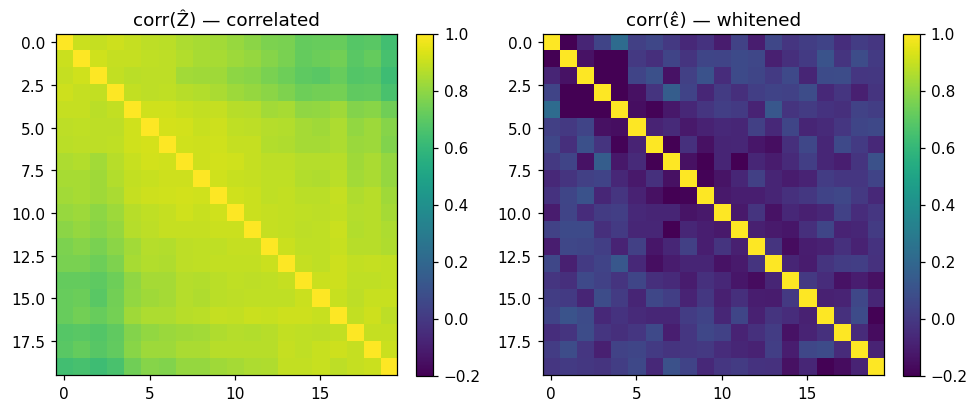

off-diag |corr|:  Ẑ (correlated) = 0.843   ε̂ (whitened, →0) = 0.076
Note: exact ε-values are noisier to recover (whitening amplifies per-obs MAP noise for tight blocks), but the de-correlation structure is clean — which is what the estimator needs.


In [5]:
Zs, Es = [], []
with torch.no_grad():
    for r in range(400):
        Zh, Eh = enc.encode_block(yB[r, idx], tb)
        Zs.append(Zh[:, 0].numpy()); Es.append(Eh[:, 0].numpy())
Cz_hat = np.corrcoef(np.array(Zs).T); Ce_hat = np.corrcoef(np.array(Es).T)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, M, ttl in [(ax[0], Cz_hat, "corr(Ẑ) — correlated"), (ax[1], Ce_hat, "corr(ε̂) — whitened")]:
    im = a.imshow(M, vmin=-.2, vmax=1, cmap="viridis"); a.set_title(ttl); plt.colorbar(im, ax=a, fraction=.046)
plt.tight_layout(); plt.show()
print(f"off-diag |corr|:  Ẑ (correlated) = {od(Cz_hat):.3f}   ε̂ (whitened, →0) = {od(Ce_hat):.3f}")
print("Note: exact ε-values are noisier to recover (whitening amplifies per-obs MAP "
      "noise for tight blocks), but the de-correlation structure is clean — which is "
      "what the estimator needs.")

## 5 · Why this scales — $K$-blocks, never $n\times n$

The *generator* uses the full $n$ (here 200) so the true data is fully correlated and
the $n\times n$ kernel inverts well. The *estimator's fantasies* only ever use small
$K$-blocks, which (by the GP marginal property) are exact GP draws $N(0,K_{\text{block}})$
— so every kernel solve is $K\times K$ with $K\approx10$–$20$.

In [6]:
import time
def chol_time(m, reps=20):
    A = gp.kernel(torch.sort(torch.rand(m)*20).values)
    t0 = time.time()
    for _ in range(reps): torch.linalg.cholesky(A)
    return 1e3*(time.time()-t0)/reps
print(f"cholesky cost:  K=20 block: {chol_time(20):.2f} ms   vs   full n=200: {chol_time(200):.2f} ms")
# marginal check: a directly-sampled K-block ~ N(0,K_block) matches the kernel block
with torch.no_grad():
    L = torch.linalg.cholesky(gp.kernel(tb))
    direct = (L @ torch.randn(20, 4000, dtype=torch.float64)).numpy()   # (K, samples)
print(f"direct K-block draw off-diag |corr| = {od(np.corrcoef(direct)):.3f}  "
      f"(matches kernel {od(Kb):.3f}) — a block is a valid GP draw)")

cholesky cost:  K=20 block: 0.02 ms   vs   full n=200: 0.10 ms
direct K-block draw off-diag |corr| = 0.919  (matches kernel 0.921) — a block is a valid GP draw)


## Takeaway

The GP layer correlates the latents exactly per the kernel; the encoder recovers the
correlated latent with the ordinary MAP and **de-correlates it in one extra step**
(whiten by $L_{\text{block}}^{-1}$) to get the independent realization. Because any
$K$-block is itself a valid GP draw, the estimator can run entirely on tiny $K\times K$
blocks — the basis for a fast, composite GP-GLLVM ZQE fit (next step).